In [1]:
import pandas as pd
 
df_reviews = pd.read_csv(r"D:\python-for-data-science-main\IMDB Dataset.csv")
df_reviews

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [2]:
df_reviews[df_reviews['sentiment']=='positive']

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
...,...,...
49983,"I loved it, having been a fan of the original ...",positive
49985,Imaginary Heroes is clearly the best film of t...,positive
49989,I got this one a few weeks ago and love it! It...,positive
49992,John Garfield plays a Marine who is blinded by...,positive


In [4]:
df_positive = df_reviews[df_reviews['sentiment']=='positive'][:9000]
df_negative = df_reviews[df_reviews['sentiment']=='negative'][:1000]

In [5]:
df_reviews_imb = pd.concat([df_positive, df_negative])
df_reviews_imb

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
...,...,...
2000,Stranded in Space (1972) MST3K version - a ver...,negative
2005,"I happened to catch this supposed ""horror"" fli...",negative
2007,waste of 1h45 this nasty little film is one to...,negative
2010,Warning: This could spoil your movie. Watch it...,negative


In [6]:
df_reviews_imb.value_counts('sentiment')

sentiment
positive    9000
negative    1000
dtype: int64

<AxesSubplot:xlabel='sentiment'>

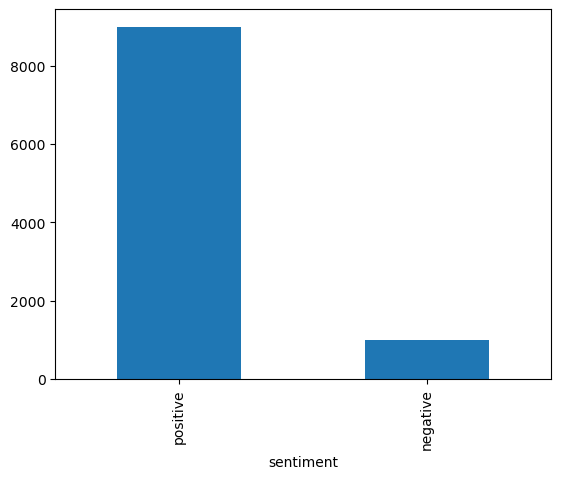

In [7]:
df_reviews_imb.value_counts('sentiment').plot(kind='bar')

In [8]:
length_negative = len(df_reviews_imb[df_reviews_imb['sentiment']=='negative'])

In [10]:
length_negative

1000

In [15]:
df_reviews_positive = df_reviews_imb[df_reviews_imb['sentiment']=='positive'].sample(n=length_negative)

In [14]:
df_reviews_negative = df_reviews_imb[df_reviews_imb['sentiment']=='negative']

In [16]:
pd.concat([df_reviews_positive, df_reviews_negative])

,review,sentiment
5367,One True Thing proves that it's the characters...,positive
7821,definitely needed a little work in season 2. S...,positive
12549,I saw this in 1993 on a VHS tape but have been...,positive
14936,'Fame' (1980) is brilliant. It's got all these...,positive
18112,I finally purchased and added to my collection...,positive
...,...,...
2000,Stranded in Space (1972) MST3K version - a ver...,negative
2005,"I happened to catch this supposed ""horror"" fli...",negative
2007,waste of 1h45 this nasty little film is one to...,negative
2010,Warning: This could spoil your movie. Watch it...,negative


In [23]:
df_reviews_bal = pd.concat([df_reviews_positive, df_reviews_negative])

In [24]:
df_reviews_bal

,review,sentiment
5367,One True Thing proves that it's the characters...,positive
7821,definitely needed a little work in season 2. S...,positive
12549,I saw this in 1993 on a VHS tape but have been...,positive
14936,'Fame' (1980) is brilliant. It's got all these...,positive
18112,I finally purchased and added to my collection...,positive
...,...,...
2000,Stranded in Space (1972) MST3K version - a ver...,negative
2005,"I happened to catch this supposed ""horror"" fli...",negative
2007,waste of 1h45 this nasty little film is one to...,negative
2010,Warning: This could spoil your movie. Watch it...,negative


In [26]:
df_reviews_bal.reset_index(drop=True, inplace=True)

In [27]:
df_reviews_bal

,review,sentiment
0,One True Thing proves that it's the characters...,positive
1,definitely needed a little work in season 2. S...,positive
2,I saw this in 1993 on a VHS tape but have been...,positive
3,'Fame' (1980) is brilliant. It's got all these...,positive
4,I finally purchased and added to my collection...,positive
...,...,...
1995,Stranded in Space (1972) MST3K version - a ver...,negative
1996,"I happened to catch this supposed ""horror"" fli...",negative
1997,waste of 1h45 this nasty little film is one to...,negative
1998,Warning: This could spoil your movie. Watch it...,negative


In [28]:
df_reviews_bal.value_counts('sentiment')

sentiment
negative    1000
positive    1000
dtype: int64

In [29]:
df_reviews_bal.reset_index(drop=True, inplace=True)

In [30]:
df_reviews_bal

,review,sentiment
0,One True Thing proves that it's the characters...,positive
1,definitely needed a little work in season 2. S...,positive
2,I saw this in 1993 on a VHS tape but have been...,positive
3,'Fame' (1980) is brilliant. It's got all these...,positive
4,I finally purchased and added to my collection...,positive
...,...,...
1995,Stranded in Space (1972) MST3K version - a ver...,negative
1996,"I happened to catch this supposed ""horror"" fli...",negative
1997,waste of 1h45 this nasty little film is one to...,negative
1998,Warning: This could spoil your movie. Watch it...,negative


In [31]:
df_reviews_bal.value_counts('sentiment')

sentiment
negative    1000
positive    1000
dtype: int64

In [32]:
!pip install imblearn

     -------------------------------------- 258.3/258.3 kB 2.6 MB/s eta 0:00:00
     -------------------------------------- 308.4/308.4 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0


In [36]:
# balancing data with RandomUserSampler

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=0)

df_review_bal, df_review_bal['sentiment'] = rus.fit_resample(df_reviews_imb[['review']], 
                                              df_reviews_imb['sentiment'])

In [37]:
df_review_bal

,review,sentiment
3,Basically there's a family where a little boy ...,negative
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
10,Phil the Alien is one of those quirky films wh...,negative
11,I saw this movie when I was about 12 when it c...,negative
...,...,...
10833,Knute Rockne led an extraordinary life and his...,positive
1039,At the height of the 'Celebrity Big Brother' r...,positive
5255,This is another of Robert Altman's underrated ...,positive
12237,This movie won a special award at Cannes for i...,positive


In [38]:
df_review_bal.value_counts('sentiment')

sentiment
negative    1000
positive    1000
dtype: int64

In [39]:
df_reviews_imb.value_counts('sentiment')

sentiment
positive    9000
negative    1000
dtype: int64

In [40]:
#splitting data into train and test

from sklearn.model_selection import train_test_split

train, test = train_test_split(df_reviews_bal, test_size=0.33, 
                               random_state=42)

In [41]:
train

,review,sentiment
81,This film is an excellent military movie. It m...,positive
915,It occurred to me while the final scene of the...,positive
1018,The plot is about the death of little children...,negative
380,This is one of may all-time favourite films. P...,positive
1029,The Hills Have Eyes II is what you would expec...,negative
...,...,...
1130,"Apparently, The Mutilation Man is about a guy ...",negative
1294,This movie pretty much sucked. I'm in the Army...,negative
860,Wagon Master is a very unique film amongst Joh...,positive
1459,"""ZZZZZZZZZZZZZZZZZZ""! If IMDb would allow one-...",negative


In [42]:
test

,review,sentiment
1860,"Obviously, the comments above that fawn over t...",negative
353,"Ghillie a remake of the Telugu ""okkadu' is tha...",positive
1333,The cast of this film contain some of New Zeal...,negative
905,If it were possible to distill the heart and s...,positive
1289,"""I presume you are here for damage to your men...",negative
...,...,...
118,Brilliant actors and brilliant picture!! I lov...,positive
1249,Steve McQueen has certainly a lot of loyal fan...,negative
1993,"This movie, despite its list of B, C, and D li...",negative
522,"Like almost everyone, I am familiar with the m...",positive


In [44]:
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

In [45]:
train_x

81      This film is an excellent military movie. It m...
915     It occurred to me while the final scene of the...
1018    The plot is about the death of little children...
380     This is one of may all-time favourite films. P...
1029    The Hills Have Eyes II is what you would expec...
                              ...                        
1130    Apparently, The Mutilation Man is about a guy ...
1294    This movie pretty much sucked. I'm in the Army...
860     Wagon Master is a very unique film amongst Joh...
1459    "ZZZZZZZZZZZZZZZZZZ"! If IMDb would allow one-...
1126    When the opening shot is U.S. Marines seriousl...
Name: review, Length: 1340, dtype: object

In [46]:
train_y

81      positive
915     positive
1018    negative
380     positive
1029    negative
          ...   
1130    negative
1294    negative
860     positive
1459    negative
1126    negative
Name: sentiment, Length: 1340, dtype: object

In [47]:
train_y.value_counts()

positive    675
negative    665
Name: sentiment, dtype: int64

In [49]:
# Count Vectorizer

from sklearn.feature_extraction.text import CountVectorizer

text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]

df = pd.DataFrame({'review':['review1', 'review2'], 'text':text})
cv = CountVectorizer(stop_words='english')
cv_matrix = cv.fit_transform(df['text'])

In [50]:
df_dtm = pd.DataFrame(cv_matrix.toarray(), index=df['review'].values,
                     columns=cv.get_feature_names())

C:\Users\asus\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [51]:
df_dtm

,code,hate,java,love,python,writing
review1,2,0,0,2,2,1
review2,2,2,2,0,0,1


In [57]:
# Tfidf

from sklearn.feature_extraction.text import TfidfVectorizer

text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]

df = pd.DataFrame({'review':['review1', 'review2'], 'text':text})
tfidf = TfidfVectorizer(stop_words='english', norm=None)
tfidf_matrix = tfidf.fit_transform(df['text'])

In [58]:
pd.DataFrame(tfidf_matrix.toarray(), index=df['review'].values,
                              columns=tfidf.get_feature_names())

C:\Users\asus\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,code,hate,java,love,python,writing
review1,2.0,0.00000,0.00000,2.81093,2.81093,1.0
review2,2.0,2.81093,2.81093,0.00000,0.00000,1.0


In [61]:
#Turning text data into numerical vectors

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
train_x_vector = tfidf.fit_transform(train_x)

In [62]:
train_x_vector

<1340x20556 sparse matrix of type '<class 'numpy.float64'>'
	with 117736 stored elements in Compressed Sparse Row format>

In [65]:
train_x

81      This film is an excellent military movie. It m...
915     It occurred to me while the final scene of the...
1018    The plot is about the death of little children...
380     This is one of may all-time favourite films. P...
1029    The Hills Have Eyes II is what you would expec...
                              ...                        
1130    Apparently, The Mutilation Man is about a guy ...
1294    This movie pretty much sucked. I'm in the Army...
860     Wagon Master is a very unique film amongst Joh...
1459    "ZZZZZZZZZZZZZZZZZZ"! If IMDb would allow one-...
1126    When the opening shot is U.S. Marines seriousl...
Name: review, Length: 1340, dtype: object

In [63]:
train_x_vector.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [64]:
pd.DataFrame.sparse.from_spmatrix(train_x_vector,
                                 index=train_x.index,
                                 columns=tfidf.get_feature_names())

C:\Users\asus\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,00,000,02,04,06th,08,09,10,100,1000,...,zoot,zorro,zuckers,zzzzzzzzzzzzzzzzzz,âge,æon,ça,élan,émigrés,être
81,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
915,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1029,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.106244,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028157,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.183829,0.0,0.0,0.0,0.0,0.0,0.0


In [66]:
test_x_vector = tfidf.transform(test_x)

In [67]:
# model selection

from sklearn.svm import SVC

svc = SVC(kernel='linear')
svc.fit(train_x_vector, train_y)

SVC(kernel='linear')

In [68]:
svc.predict(tfidf.transform(['A good movie']))

array(['positive'], dtype=object)

In [69]:
print(svc.predict(tfidf.transform(['A good movie'])))
print(svc.predict(tfidf.transform(['An excellent movie'])))
print(svc.predict(tfidf.transform(['I did not like this movie at all'])))

['positive']
['positive']
['negative']


In [77]:
# decision tree

from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier()
dec_tree.fit(train_x_vector, train_y)

DecisionTreeClassifier()

In [71]:
# naive bayes

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(train_x_vector.toarray(), train_y)

GaussianNB()

In [79]:
# logistic regression

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(train_x_vector, train_y)

LogisticRegression()

In [80]:
# confusion matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(test_y,
                svc.predict(test_x_vector),
                labels = ['positive', 'negative'])

array([[284,  41],
       [ 69, 266]], dtype=int64)

In [82]:
# mean accuracy

print(svc.score(test_x_vector, test_y))
print(dec_tree.score(test_x_vector, test_y))
print(gnb.score(test_x_vector.toarray(), test_y))
print(log_reg.score(test_x_vector, test_y))

0.8333333333333334
0.6878787878787879
0.6515151515151515
0.8212121212121212


In [83]:
# f1 score

from sklearn.metrics import f1_score

f1_score(test_y, svc.predict(test_x_vector),
        labels=['positive', 'negative'],
        average=None)

array([0.83775811, 0.82866044])

In [85]:
# classification report

from sklearn.metrics import classification_report

classification_report(test_y,
                     svc.predict(test_x_vector),
                     labels=['positive', 'negative'])

'              precision    recall  f1-score   support\n\n    positive       0.80      0.87      0.84       325\n    negative       0.87      0.79      0.83       335\n\n    accuracy                           0.83       660\n   macro avg       0.84      0.83      0.83       660\nweighted avg       0.84      0.83      0.83       660\n'

In [86]:
print(classification_report(test_y,
                     svc.predict(test_x_vector),
                     labels=['positive', 'negative'])
)

              precision    recall  f1-score   support

    positive       0.80      0.87      0.84       325
    negative       0.87      0.79      0.83       335

    accuracy                           0.83       660
   macro avg       0.84      0.83      0.83       660
weighted avg       0.84      0.83      0.83       660



In [88]:
# Grid Search CV

from sklearn.model_selection import GridSearchCV

parameters = {'C': [1,4,8,16,32], 'kernel':['linear', 'rbf']}
svc = SVC()
svc_grid = GridSearchCV(svc, parameters, cv=5)
svc_grid.fit(train_x_vector, train_y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 4, 8, 16, 32], 'kernel': ['linear', 'rbf']})

In [89]:
svc_grid.best_params_

{'C': 4, 'kernel': 'rbf'}

In [90]:
svc_grid.best_estimator_

SVC(C=4)